# Sea-surface temperature inside a selected EEZ

Select a country once. The EEZ controls the spatial subset, mask, zoom, maps and area-weighted time series.

In [1]:
from pathlib import Path
import subprocess
import sys, warnings
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
warnings.filterwarnings('ignore')

root_candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
repo_root = next((p for p in root_candidates if (p / 'data' / 'regional' / 'Pacific_EEZs' / 'Pacific_EEZs.shp').is_file()), None)
if repo_root is None: raise FileNotFoundError('Could not locate the CIndRA root containing data/regional/Pacific_EEZs/Pacific_EEZs.shp.')
data_dir = repo_root / 'data'
fig_dir = repo_root / 'matrix_cc' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

indicators_setup_dir = repo_root.parents[1] / 'indicators_setup'
if indicators_setup_dir.is_dir(): sys.path.insert(0, str(indicators_setup_dir))
sys.path.insert(0, str(repo_root / 'functions'))
from data_downloaders import download_oni_index
from sst import normalise_name, plot_map, plot_panels, resolve_eez_sst, setup_map
from ind_setup.plotting import plot_bar_probs, fontsize
from ind_setup.plotting_int import plot_timeseries_interactive, plot_oni_index_th
from ind_setup.tables import style_matrix, table_ocean

## 1. Selection

In [2]:
country = 'Palau'
sst_url = (
    'https://downloads.psl.noaa.gov/Datasets/'
    'noaa.oisst.v2.highres/sst.mon.mean.nc'
)
sst_file = data_dir / 'sea_surface_temperature' / 'sst.mon.mean.nc'
force_download = False
eez_file = data_dir / 'regional' / 'Pacific_EEZs' / 'Pacific_EEZs.shp'
dataset_id = 'sst'
map_padding_degrees = 0.5
years_to_plot = range(1982, 2024)  # None plots every available year

## 2. Download NOAA OISST and crop it to the selected EEZ

Sea-surface temperature data come from the NOAA Optimum Interpolation Sea Surface Temperature (OISST) V2 high-resolution monthly-mean product, distributed by the NOAA Physical Sciences Laboratory at 0.25° spatial resolution. The source dataset is [`sst.mon.mean.nc`](https://downloads.psl.noaa.gov/Datasets/noaa.oisst.v2.highres/sst.mon.mean.nc), available from the [NOAA OISST V2 high-resolution archive](https://downloads.psl.noaa.gov/Datasets/noaa.oisst.v2.highres/). The notebook stores the downloaded file under `data/sea_surface_temperature/` and then crops it to the selected EEZ.

In [3]:
sst_file.parent.mkdir(parents=True, exist_ok=True)
temporary_file = sst_file.with_suffix(sst_file.suffix + '.part')
if force_download and temporary_file.exists():
    temporary_file.unlink()
if force_download or not sst_file.is_file():
    print(f'Downloading NOAA OISST to {temporary_file} (resumable) ...')
    subprocess.run(
        [
            'curl', '--location', '--fail', '--retry', '5', '--retry-all-errors',
            '--connect-timeout', '30', '--continue-at', '-',
            '--output', str(temporary_file), sst_url,
        ],
        check=True,
    )
    temporary_file.replace(sst_file)
    print(f'Download complete ({sst_file.stat().st_size / 1024**2:.1f} MB).')
else:
    print(f'Using cached NOAA OISST: {sst_file} ({sst_file.stat().st_size / 1024**2:.1f} MB).')

Using cached NOAA OISST: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/CIndRA/data/sea_surface_temperature/sst.mon.mean.nc (2131.9 MB).


In [4]:
print(f'Opening SST data: {sst_file}')
region = resolve_eez_sst(country, eez_file, sst_file, dataset_id, map_padding_degrees)
country_name = region.country_name
data_raw, data, eez_mask = region.data_raw, region.data, region.mask
lon_site, lat_site = region.representative_lon, region.representative_lat
print(f'{country_name}: {int(eez_mask.sum())} SST cells; extent {region.lon_range} x {region.lat_range}')

Opening SST data: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/CIndRA/data/sea_surface_temperature/sst.mon.mean.nc
Palau: 796 SST cells; extent (128.98969953085728, 137.47550962800014) x (1.1487128810002787, 11.941767356000156)


## 3. Plotting setup

In [5]:
projection = ccrs.PlateCarree()
slug = '_'.join(normalise_name(country_name).split())

## 4. Mean and trend maps

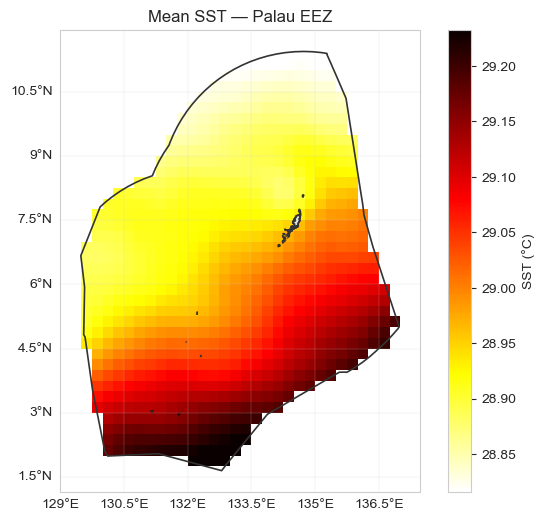

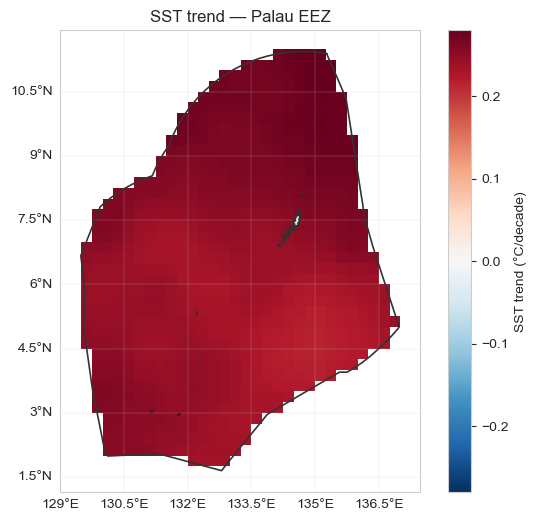

In [6]:
sst_mean = data[dataset_id].mean('time')
vmin, vmax = np.nanpercentile(sst_mean, [1, 99])
fig, ax = plot_map(sst_mean, f'Mean SST — {country_name} EEZ', 'hot_r', region, vmin, vmax, filename=fig_dir / f'SST_mean_{slug}.png')

annual = data[dataset_id].resample(time='YS').mean()
year = xr.DataArray(annual.time.dt.year.astype(float), coords={'time': annual.time}, dims='time')
trend_decade = xr.cov(annual, year, dim='time') / year.var('time') * 10
limit = float(np.nanpercentile(np.abs(trend_decade), 99))
fig, ax = plot_map(trend_decade, f'SST trend — {country_name} EEZ', 'RdBu_r', region, -limit, limit, 'SST trend (°C/decade)', fig_dir / f'SST_trend_{slug}.png')

## 5. Seasonal mean and anomaly

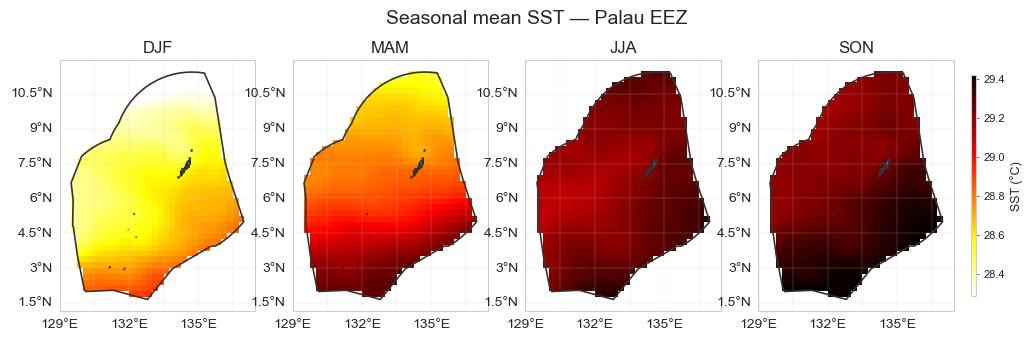

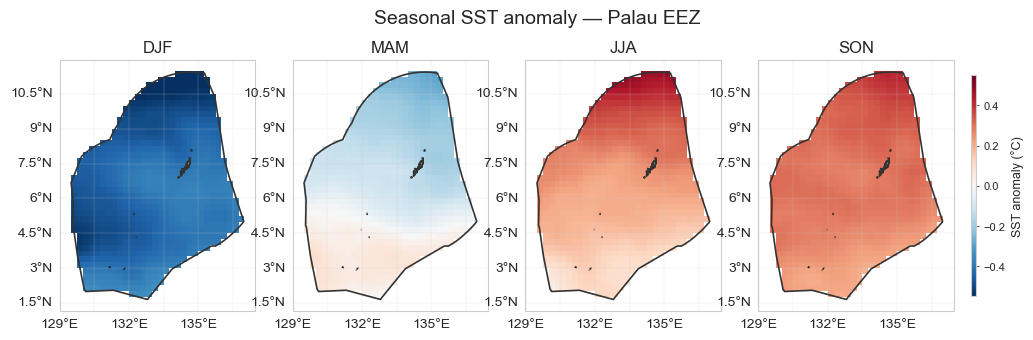

In [7]:
seasonal = data[dataset_id].groupby('time.season').mean().sel(season=['DJF','MAM','JJA','SON'])
vmin, vmax = np.nanpercentile(seasonal, [1, 99])
fig = plot_panels(seasonal, 'season', f'Seasonal mean SST — {country_name} EEZ', 'hot_r', region, vmin, vmax)
seasonal_anomaly = seasonal - sst_mean
limit = float(np.nanpercentile(np.abs(seasonal_anomaly), 99))
fig = plot_panels(seasonal_anomaly, 'season', f'Seasonal SST anomaly — {country_name} EEZ', 'RdBu_r', region, -limit, limit, 'SST anomaly (°C)')

## 6. Annual mean and anomaly maps

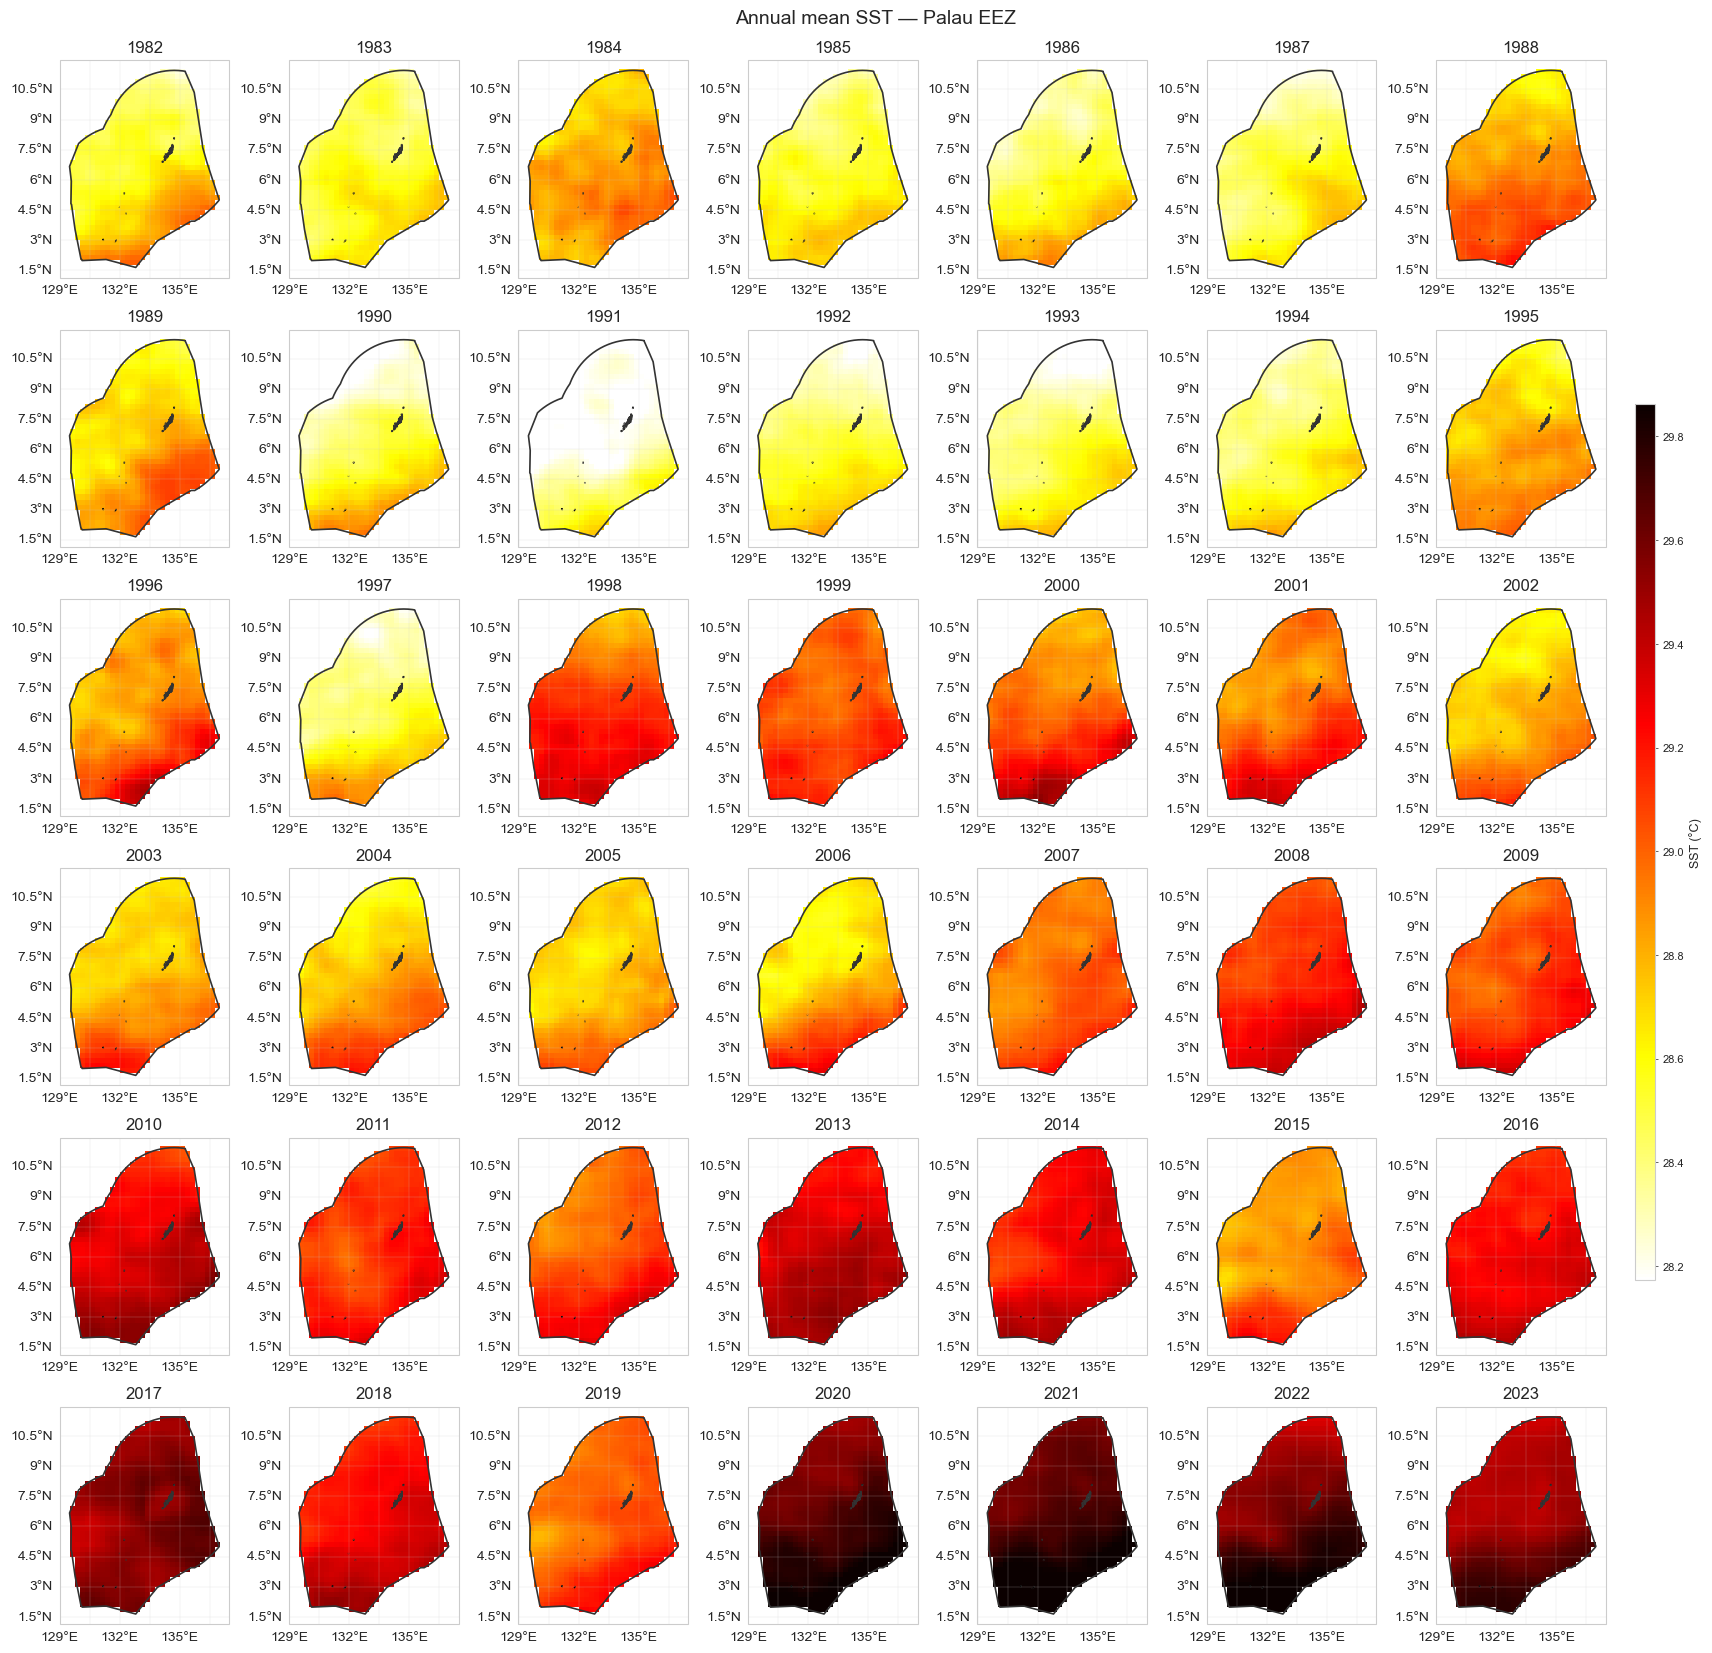

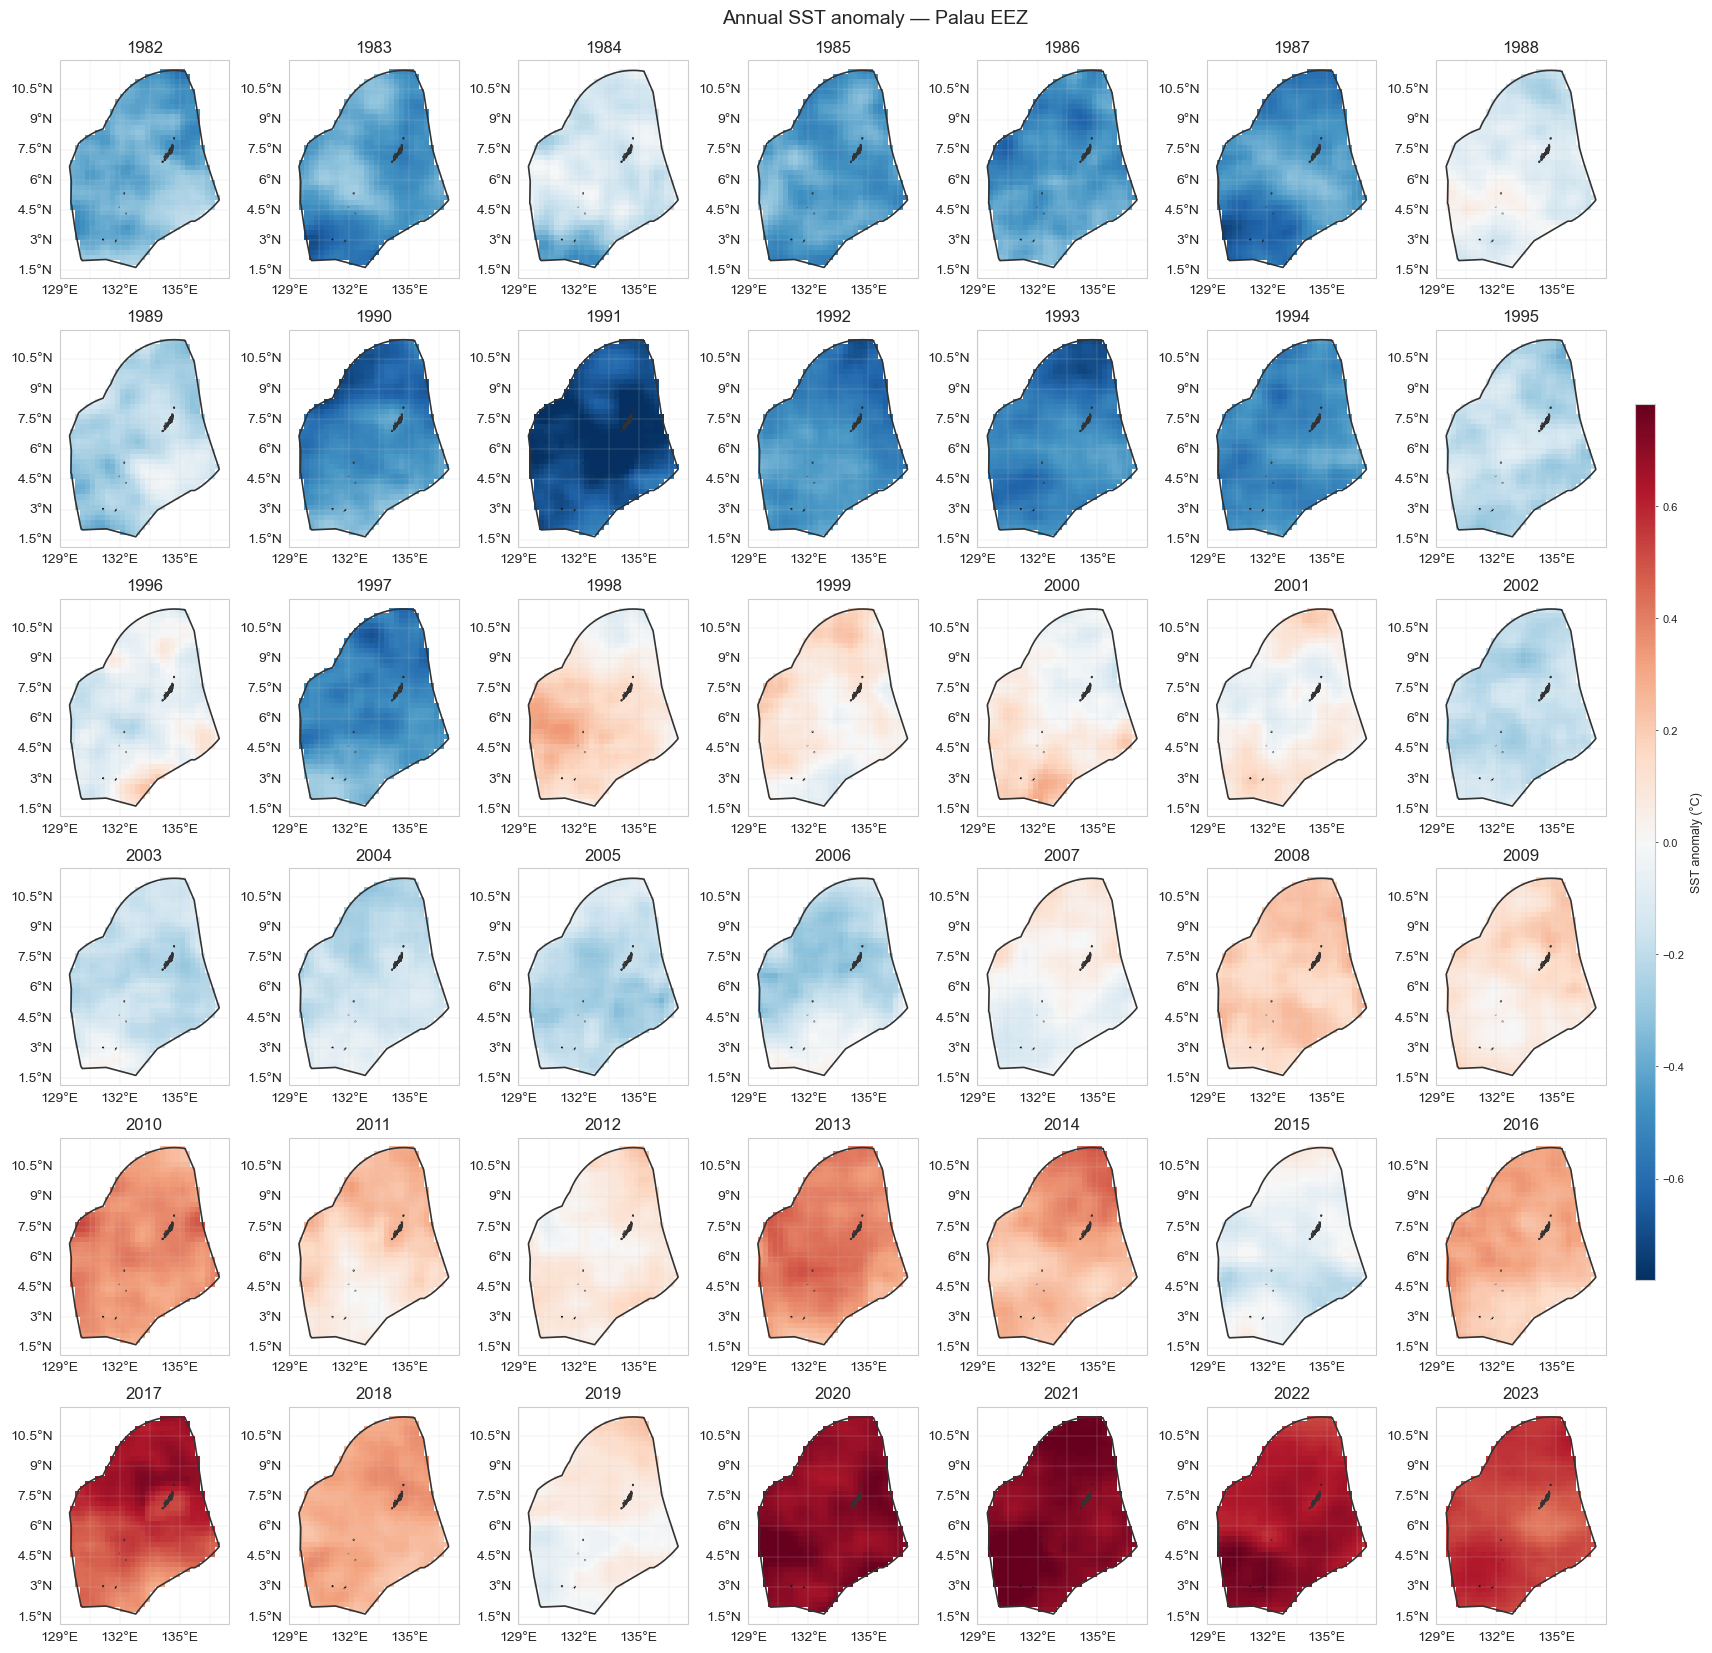

In [8]:
annual_plot = annual if years_to_plot is None else annual.sel(time=annual.time.dt.year.isin(list(years_to_plot)))
if annual_plot.time.size == 0: raise ValueError('None of years_to_plot occurs in the SST record.')
vmin, vmax = np.nanpercentile(annual_plot, [1, 99])
fig = plot_panels(annual_plot, 'time', f'Annual mean SST — {country_name} EEZ', 'hot_r', region, vmin, vmax)
annual_anomaly = annual_plot - sst_mean
limit = float(np.nanpercentile(np.abs(annual_anomaly), 99))
fig = plot_panels(annual_anomaly, 'time', f'Annual SST anomaly — {country_name} EEZ', 'RdBu_r', region, -limit, limit, 'SST anomaly (°C)')

## 7. Average area

In [9]:
weights = np.cos(np.deg2rad(data.lat)).broadcast_like(eez_mask).where(eez_mask, 0).fillna(0)
sst_daily = data[dataset_id].weighted(weights).mean(('lat','lon'))
sst_annual = sst_daily.resample(time='YS').mean()
annual_df = sst_annual.to_dataframe(name=dataset_id).dropna()
top_10 = annual_df.nlargest(10, dataset_id)
x = annual_df.index.year.to_numpy(); y = annual_df[dataset_id].to_numpy()
slope, intercept = np.polyfit(x, y, 1)

## 8. Given point

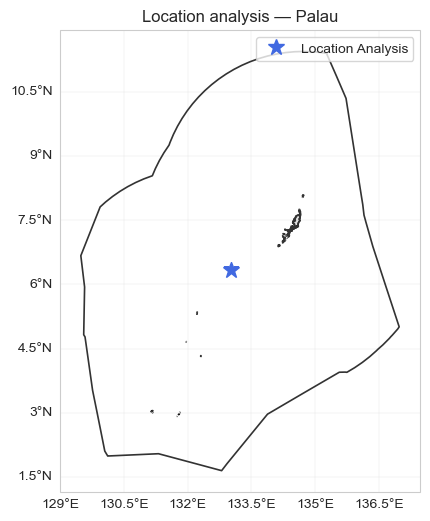

In [10]:
location = None  # (latitude, longitude); None uses an EEZ representative point
point_lat, point_lon = (lat_site, lon_site) if location is None else location
point_sst = data_raw[dataset_id].sel(lat=point_lat, lon=point_lon, method='nearest')

fig_point, ax_point = plt.subplots(figsize=(10, 6), subplot_kw={'projection': projection})
setup_map(ax_point, f'Location analysis — {country_name}', region, projection)
ax_point.plot(point_lon, point_lat, '*', markersize=12, color='royalblue', transform=projection, label='Location Analysis')
ax_point.legend()

### Original post-annual analyses

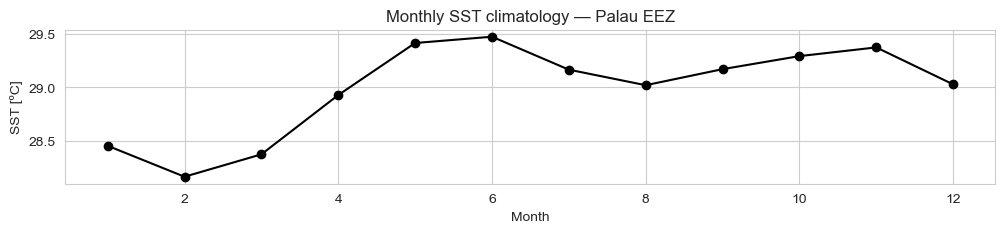

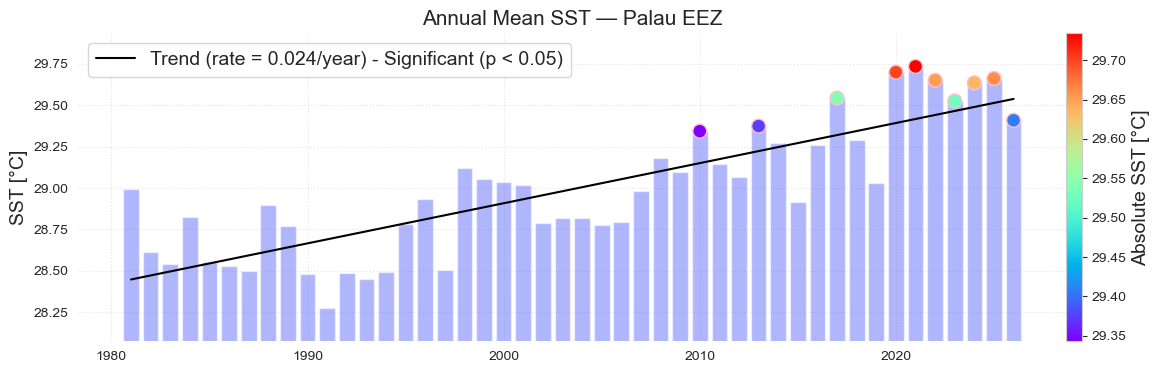

In [11]:
# Interactive area-average series
data_mean = sst_daily.to_dataframe(name=dataset_id).dropna()
dict_plot = [{'data': data_mean, 'var': dataset_id, 'ax': 1, 'label': 'SST [ºC]'}]
fig = plot_timeseries_interactive(dict_plot, trendline=True, scatter_dict=None, figsize=(25, 12), label_yaxes='SST [ºC]')

# Monthly climatology
fig_monthly, ax = plt.subplots(figsize=(12, 2))
sst_daily.groupby('time.month').mean().plot(ax=ax, marker='o', color='k')
ax.set(title=f'Monthly SST climatology — {country_name} EEZ', xlabel='Month', ylabel='SST [ºC]')

# Keep the annual ranking/trend objects expected by the summary table
nevents = 10
data_mean_annual = data_mean.resample('YE').mean()
top_10 = data_mean_annual.sort_values(by=dataset_id, ascending=False).head(nevents)
fig_bar, ax_bar, trend = plot_bar_probs(x=data_mean_annual.index.year, y=data_mean_annual[dataset_id], trendline=True, y_label='SST [°C]', figsize=[15, 4], return_trend=True)
ax_bar.set_ylim(data_mean_annual[dataset_id].min()-.2, data_mean_annual[dataset_id].max()+.2)
im = ax_bar.scatter(top_10.index.year, top_10[dataset_id], c=top_10[dataset_id].values, s=100, ec='pink', cmap='rainbow', label='Top 10 warmest years')
plt.colorbar(im, ax=ax_bar, pad=0).set_label('Absolute SST [°C]', fontsize=fontsize)
ax_bar.set_title(f'Annual Mean SST — {country_name} EEZ', fontsize=15)
fig_bar.savefig(fig_dir / f'SST_trends_anomalies_{slug}.png', dpi=300, bbox_inches='tight')

## 9. ONI index analysis

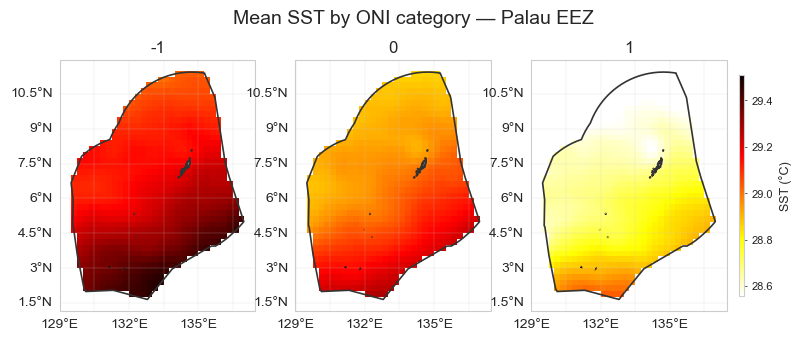

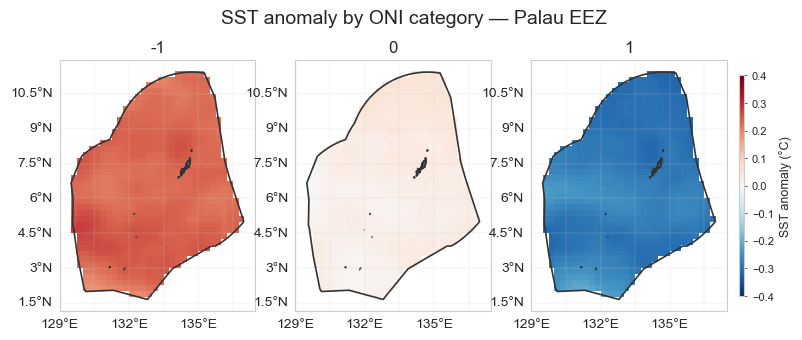

In [12]:
p_data = 'https://psl.noaa.gov/data/correlation/oni.data'
df1 = download_oni_index(p_data)
lims = [-.5, .5]
plot_oni_index_th(df1, lims=lims)

data_monthly = data.resample(time='MS').mean()
oni_aligned = df1['ONI'].reindex(pd.DatetimeIndex(data_monthly.time.values))
data_monthly['ONI'] = ('time', oni_aligned.to_numpy())
data_monthly['ONI_cat'] = ('time', np.where(data_monthly.ONI < lims[0], -1, np.where(data_monthly.ONI > lims[1], 1, 0)))
data_oni = data_monthly.groupby('ONI_cat').mean()
oni_mean = data_oni[dataset_id]
vmin, vmax = np.nanpercentile(data_monthly[dataset_id].mean('time'), [0, 100]) + np.array([-.25, .25])
fig_oni = plot_panels(oni_mean, 'ONI_cat', f'Mean SST by ONI category — {country_name} EEZ', 'hot_r', region, vmin, vmax)
fig_oni.savefig(fig_dir / f'SST_ENSO_{slug}.png', dpi=300, bbox_inches='tight')
data_an_oni = oni_mean - data_monthly[dataset_id].mean('time')
fig_oni_an = plot_panels(data_an_oni, 'ONI_cat', f'SST anomaly by ONI category — {country_name} EEZ', 'RdBu_r', region, -.4, .4, 'SST anomaly (°C)')

## 10. Table

In [13]:
style_matrix(table_ocean(data, trend, data_oni, dataset_id))

Metric,Value
Daily Average,28.989
Daily Maximum 01/09/1998,30.434
Daily Minimum 01/02/1991,26.902
Maximum Annual Average,29.734
Minimum Annual Average,28.275
Rate of change [°C/year],0.024
Change between 1981 and 2026 [°C],1.080
,
Average La Niña sst,29.220
Average El Niño sst,28.709
